In [2]:
import numpy as np

In [3]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

# Q-1

In [4]:
data = np.random.normal(loc=50, scale=10, size=1000)

print(data[:10])

[70.05038067 29.88454284 52.17670779 53.83363672 49.65838138 62.59513965
 63.89291015 38.72871391 53.19434267 59.13661862]


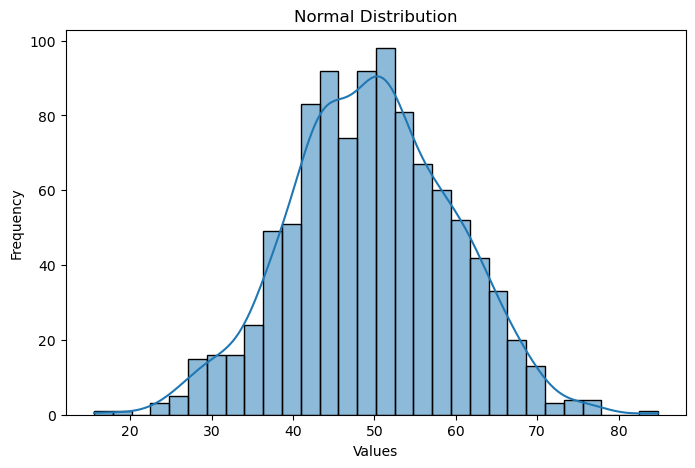

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(data, bins=30,kde=True)

plt.title("Normal Distribution")
plt.xlabel("Values")
plt.ylabel("Frequency")

plt.show()

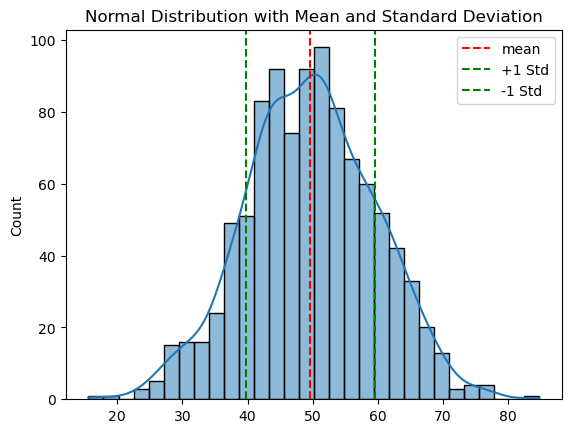

In [6]:
mean=np.mean(data)
std=np.std(data)
sns.histplot(data,bins=30,kde=True)
plt.axvline(mean,color='red',linestyle='--',label="mean")
plt.axvline(mean+std, color='green', linestyle='--', label='+1 Std')
plt.axvline(mean-std, color='green', linestyle='--', label='-1 Std')
plt.legend()

plt.title("Normal Distribution with Mean and Standard Deviation")

plt.show()

In [7]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [25]:
from scipy import stats

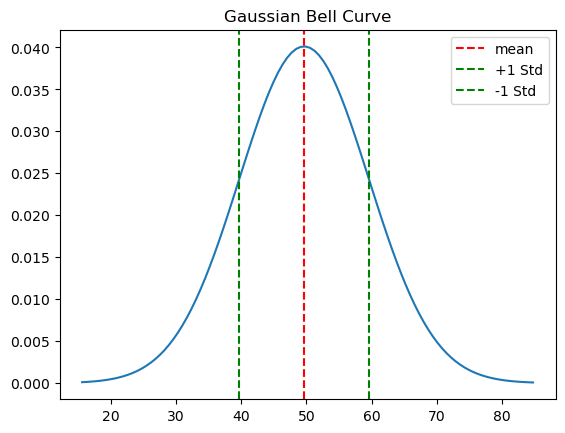

In [26]:
x=np.linspace(min(data),max(data),100)
y=stats.norm.pdf(x,mean,std)
plt.plot(x, y)
plt.axvline(mean,color='red',linestyle='--',label="mean")
plt.axvline(mean+std, color='green', linestyle='--', label='+1 Std')
plt.axvline(mean-std, color='green', linestyle='--', label='-1 Std')
plt.legend()

plt.title("Gaussian Bell Curve")

plt.show()

# Q-2

In [10]:


df = pd.DataFrame({
    "marks":[45,67,89,56,78,90,72,81,63,59,95,84,76,69,88]
})

df

,marks
0,45
1,67
2,89
3,56
4,78
5,90
6,72
7,81
8,63
9,59


In [11]:
q1=np.percentile(df['marks'], 25)
q2=np.percentile(df['marks'], 50)
q3=np.percentile(df['marks'], 75)
print("Q1 =",q1)
print("Median =",q2)
print("Q3 =",q3)

Q1 = 65.0
Median = 76.0
Q3 = 86.0


In [12]:
#using pandas
print(df["marks"].quantile(0.25))
print(df["marks"].quantile(0.50))
print(df["marks"].quantile(0.75))

65.0
76.0
86.0


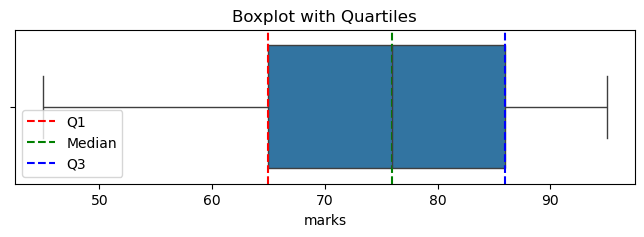

In [29]:
plt.figure(figsize=(8,2))

sns.boxplot(x=df["marks"])

# Draw Quartile Lines
plt.axvline(q1, color='red', linestyle='--', label='Q1')
plt.axvline(q2, color='green', linestyle='--', label='Median')
plt.axvline(q3, color='blue', linestyle='--', label='Q3')

plt.title("Boxplot with Quartiles")
plt.legend(loc='lower left')

plt.show()

# Q-3

In [14]:
minimum = df["marks"].min()
q1 = df["marks"].quantile(0.25)
median = df["marks"].median()
q3 = df["marks"].quantile(0.75)
maximum = df["marks"].max()

print("Minimum :",minimum)
print("Q1 :",q1)
print("Median :",median)
print("Q3 :",q3)
print("Maximum :",maximum)

Minimum : 45
Q1 : 65.0
Median : 76.0
Q3 : 86.0
Maximum : 95


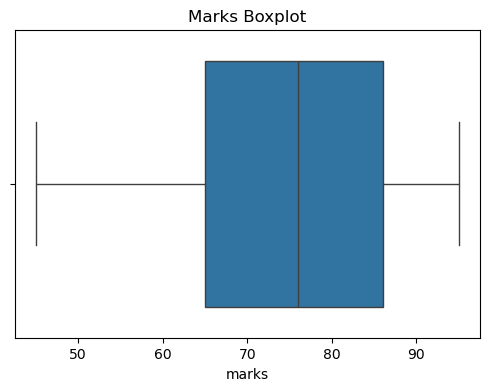

In [15]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["marks"])

plt.title("Marks Boxplot")

plt.show()

In [16]:
IQR = q3-q1

lower = q1-1.5*IQR
upper = q3+1.5*IQR

outliers = df[(df["marks"]<lower) | (df["marks"]>upper)]

print(outliers)

Empty DataFrame
Columns: [marks]
Index: []


# Inferential Statistics

Inferential Statistics is the branch of statistics that uses sample data to make predictions or draw conclusions about a population.

## Real-world Applications

- Election Polling
- Clinical Trials
- A/B Testing
- Market Research
- Customer Satisfaction Surveys

In [17]:
population = pd.DataFrame({
    "Salary": np.random.normal(50000,8000,1000)
})

population.head()

,Salary
0,60582.168343
1,49081.853989
2,41599.062122
3,34401.429536
4,46809.602342


In [18]:
population_mean = population["Salary"].mean()

print("Population Mean =",population_mean)

Population Mean = 49820.26545177889


In [40]:
sample = population.sample(n=100,random_state=42)

sample.head()

,Salary
521,58462.997814
737,46459.824154
740,48829.342292
660,49230.828540
411,56533.942605


In [20]:
sample_mean = sample["Salary"].mean()

print("Sample Mean =",sample_mean)

Sample Mean = 49542.34701559537


In [21]:
print("Population Mean :",population_mean)

print("Sample Mean :",sample_mean)

Population Mean : 49820.26545177889
Sample Mean : 49542.34701559537


In [22]:
sample_means = []

for i in range(100):

    sample = population.sample(n=100)

    sample_means.append(sample["Salary"].mean())

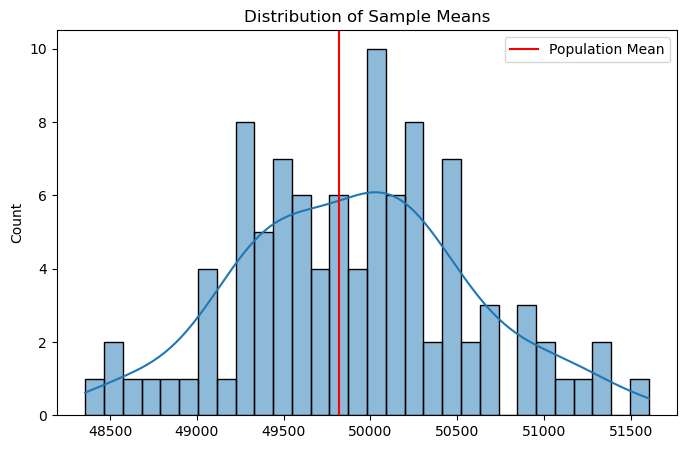

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(sample_means, bins=30, kde=True)

plt.axvline(population_mean,color='red',label='Population Mean')

plt.legend()

plt.title("Distribution of Sample Means")

plt.show()